In [2]:
import numpy as np
import matplotlib.pyplot as plt

import healpy as hp

import pandas as pd

from astropy.io import fits

In [3]:
gal_south = np.load("galaxy_south_reduced.npz")
gal_north = np.load("galaxy_north_reduced.npz")
rand_south = np.load("random_south_reduced.npz")
rand_north = np.load("random_north_reduced.npz")

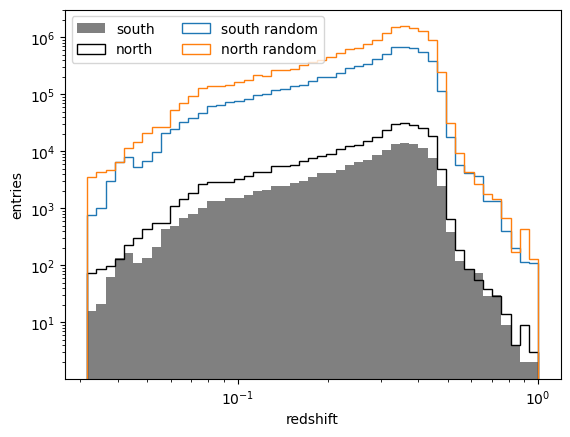

In [4]:
z_bins = np.logspace(-1.5, 0, 50)
plt.hist(gal_south["z"], bins=z_bins, color='gray', label='south')
plt.hist(gal_north["z"], bins=z_bins, histtype='step', color='black', label='north')
plt.hist(rand_south["z"], bins=z_bins, histtype='step', label='south random')
plt.hist(rand_north["z"], bins=z_bins, histtype='step', label='north random')

plt.xscale('log')
plt.xlabel('redshift')

plt.yscale('log')
plt.ylabel('entries')

plt.legend(loc=2, ncol=2)

plt.show()

In [5]:
gal_north1 = np.array([gal_north["ra"], gal_north["dec"], gal_north["z"]])
gal_south1 = np.array([gal_south["ra"], gal_south["dec"], gal_south["z"]])
gal = np.hstack((gal_north1, gal_south1)).T
galaxies = pd.DataFrame(gal, columns=["ra", "dec", "z"])

In [6]:
rand_north1 = np.array([rand_north["ra"], rand_north["dec"], rand_north["z"]])
rand_south1 = np.array([rand_south["ra"], rand_south["dec"], rand_south["z"]])
rand = np.hstack((rand_north1, rand_south1)).T
randoms = pd.DataFrame(rand, columns=["ra", "dec", "z"])

In [7]:
np.savez("./boss-clean", ra=galaxies["ra"], dec=galaxies["dec"], z=galaxies["z"])

In [35]:
# choose only good galaxies:
galaxies = galaxies[galaxies["z"] > 0.01]
randoms = randoms[randoms["z"] > 0.01]

In [36]:
# bins = [[0.01, 0.04], [0.04, 0.08], [0.08, 0.12], [0.12, 0.16], [0.16, 0.20], [0.20, 0.40]]
# bin_names = ["001-004", "004-008", "008-012", "012-016", "016-020", "020-040"]
# bins = [[0.01, 0.04], [0.04, 0.07], [0.07, 0.10], [0.10, 0.13], [0.13, 0.16], [0.16, 0.40]]
# bin_names = ["001-004", "004-007", "007-010", "010-013", "013-016", "016-040"]
bins = [[0.01, 0.04], [0.04, 0.07], [0.07, 0.10], [0.10, 0.14], [0.14, 0.18], [0.18, 0.40]]
bin_names = ["001-004", "004-007", "007-010", "010-014", "014-018", "018-040"]

gal_bins = []
ran_bins = []
for i in range(len(bins)):
    gal_bins.append(galaxies[(galaxies["z"] > bins[i][0]) * (galaxies["z"] <= bins[i][1])])
    ran_bins.append(randoms[(randoms["z"] > bins[i][0]) * (randoms["z"] <= bins[i][1])])

/tmp/ipykernel_1869162/1947509068.py:12: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  ran_bins.append(randoms[(randoms["z"] > bins[i][0]) * (randoms["z"] <= bins[i][1])])


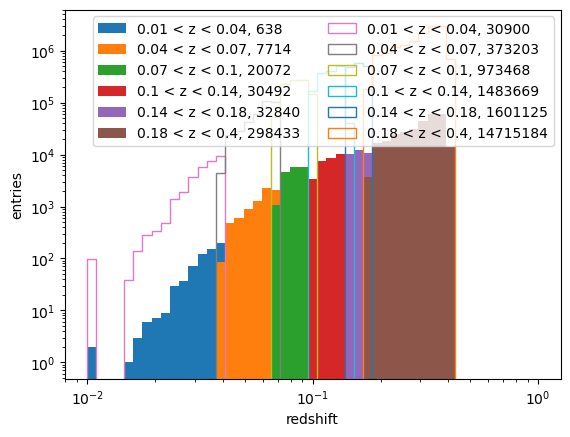

In [37]:
z_bins = np.logspace(-2, 0, 50)
for i in range(len(bins)):
    plt.hist(gal_bins[i]["z"], bins=z_bins,
             label=f"{bins[i][0]} < z < {bins[i][1]}, {gal_bins[i]['z'].size}")

for i in range(len(bins)):
    plt.hist(ran_bins[i]["z"], bins=z_bins,
             label=f"{bins[i][0]} < z < {bins[i][1]}, {ran_bins[i]['z'].size}",
             histtype="step")

plt.xscale('log')
plt.xlabel('redshift')

plt.yscale('log')
plt.ylabel('entries')

plt.legend(loc=1, ncol=2)

plt.show()

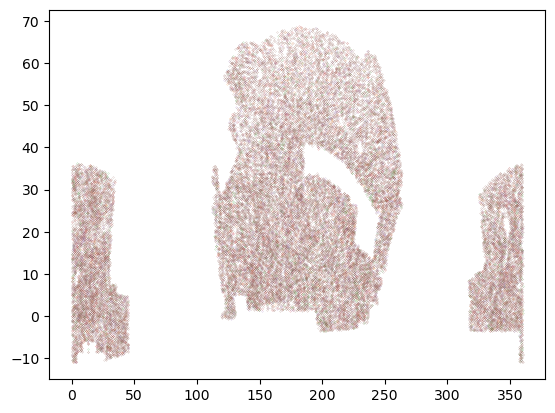

In [38]:
for i in range(len(bins)):
    plt.scatter(gal_bins[i]["ra"][::10], gal_bins[i]["dec"][::10], s=0.01)

## Healpix part

### Mask (Chat-GPT recipie)

In [40]:
from astropy.coordinates import SkyCoord

nside = 128
npix = hp.nside2npix(nside)

mask = np.zeros(npix)

ra, dec = np.array(randoms["ra"]), np.array(randoms["dec"])
z = np.array(randoms["z"])

theta_data = np.radians(90 - dec)
phi_data   = np.radians(ra)

# 1. build mask from catalog
mask = np.zeros(npix)
pix = hp.ang2pix(nside, theta_data, phi_data)
mask[pix] = 1

# 2. smooth / fill
mask = hp.smoothing(mask, sigma=np.radians(1.5))
mask = (mask > 0.5).astype(float)

# 3. apply Galactic cut (pixel space!)
theta_pix, phi_pix = hp.pix2ang(nside, np.arange(npix))
dec_pix, ra_pix = 90 - np.degrees(theta_pix), np.degrees(phi_pix)

coord = SkyCoord(ra=ra_pix, dec=dec_pix, unit='deg', frame='icrs').galactic
l_pix, b_pix = coord.l.deg, coord.b.deg
mask *= (np.abs(b_pix) > 10)

mask = np.bool_(mask)

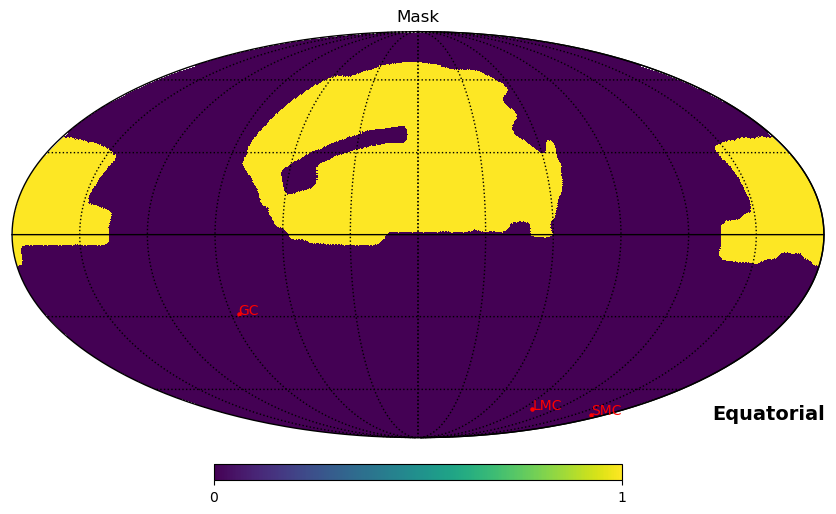

In [42]:
hp.mollview(mask, title="Mask", coord='C', rot=(180, 0, 0))

# LMC / SMC Galactic coordinates
l_gal = np.array([0, 280.5, 302.8])
b_gal = np.array([0, -32.9, -44.3])

objects = SkyCoord(l=l_gal, b=b_gal, unit='deg', frame='galactic')

# convert to healpy angles
theta_gal = np.radians(90 - b_gal)
phi_gal   = np.radians(l_gal)

# overplot
hp.projscatter(theta_gal, phi_gal, marker='o', color='red', s=5, coord='G')

# optional labels
hp.projtext(theta_gal[0], phi_gal[0], "GC", color='red', coord='G')
hp.projtext(theta_gal[1], phi_gal[1], "LMC", color='red', coord='G')
hp.projtext(theta_gal[2], phi_gal[2], "SMC", color='red', coord='G')

hp.graticule()
plt.show()

np.save("sdss_mask", mask)

### Plot overdensity

In [105]:
# prepare randoms
rar, decr = np.array(randoms["ra"]), np.array(randoms["dec"])
zr = np.array(randoms["z"])

theta_rand = np.radians(90 - decr)
phi_rand   = np.radians(rar)

In [106]:
nside = 128
npix = hp.nside2npix(nside)
print(npix)

data_bins = []
rand_bins = []

for i in range(len(bins)):
    # data
    good_i = (galaxies["z"] > bins[i][0]) * (galaxies["z"] <= bins[i][1])
    pix_i = hp.ang2pix(nside, theta_data[good_i], phi_data[good_i])
    map_i = np.bincount(pix_i, minlength=npix)
    data_bins.append(map_i)
    np.save(f"sdss_{bin_names[i]}_data", map_i)
    
    # randoms
    good_r_i = (randoms["z"] > bins[i][0]) * (randoms["z"] <= bins[i][1])
    pix_r_i = hp.ang2pix(nside, theta_rand[good_r_i], phi_rand[good_r_i])
    map_r_i = np.bincount(pix_r_i, minlength=npix)
    rand_bins.append(map_r_i)
    np.save(f"sdss_{bin_names[i]}_rand", map_r_i)

196608


/tmp/ipykernel_62502/2479788009.py:17: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  good_r_i = (randoms["z"] > bins[i][0]) * (randoms["z"] <= bins[i][1])


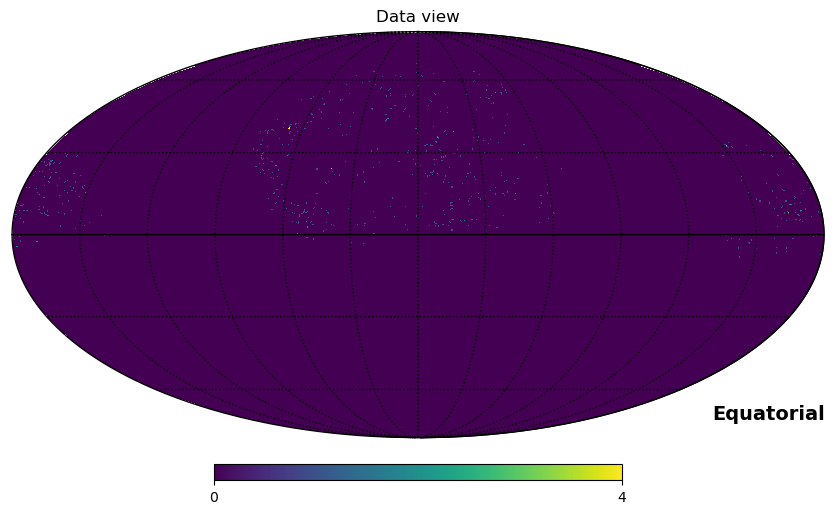

In [107]:
hp.mollview(data_bins[0], title="Data view", rot=(180, 0, 0), coord='C')
hp.graticule()

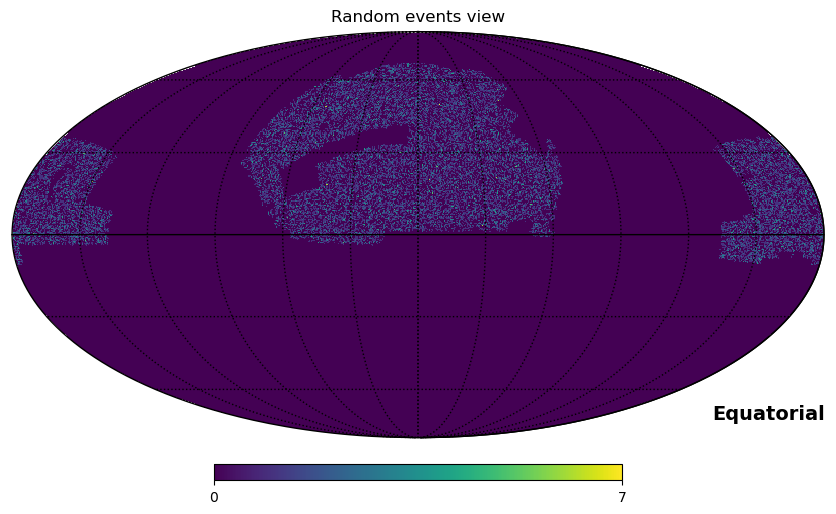

In [108]:
hp.mollview(rand_bins[0], title="Random events view", rot=(180, 0, 0), coord='C')
hp.graticule()

In [109]:
from astropy.coordinates import SkyCoord

MW_plane = SkyCoord(l=np.linspace(0, 360, 100), b=0.0, frame='galactic', unit='deg')
theta_MW, phi_MW = np.pi/2 - MW_plane.galactic.b.rad, MW_plane.galactic.l.rad

Eq_plane = SkyCoord(ra=np.linspace(0, 360, 100), dec=0.0, frame='icrs', unit='deg')
theta_Eq, phi_Eq = np.pi/2 - Eq_plane.dec.rad, Eq_plane.ra.rad

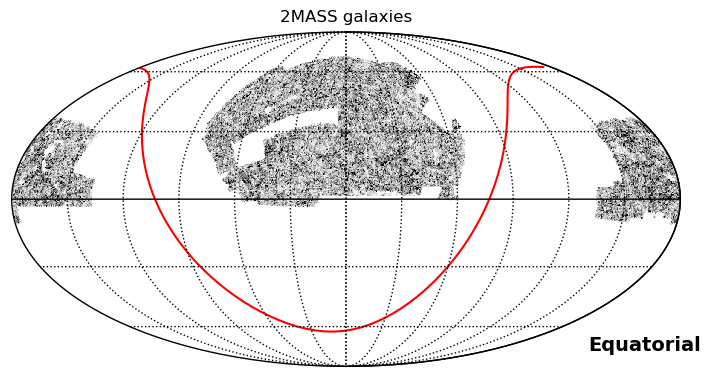

In [110]:
fig = plt.figure(figsize=(7, 4), num=1)
hp.mollview(np.sum(np.array(data_bins), axis=0), title="2MASS galaxies", rot=(180, 0, 0), coord='C', max=20, cmap='Grays', fig=1, xsize=900, cbar=False)
hp.projplot(theta_MW, phi_MW, coord='G', color='red')
hp.graticule()

In [111]:
# OVERDENSITY FUNCTION

from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

delta_bins = []
delta_bins_s = []

for i in range(len(bins)):
    # normalization coefficient (data / sampling)
    alpha_i = np.sum(data_bins[i]) / (np.sum(rand_bins[i]))
    print(f"ALPHA: {1/alpha_i:.2f}")
    delta_i = np.zeros(npix, dtype=float)
    delta_s = np.zeros(npix, dtype=float)
    
    z_avg = (bins[i][0] + bins[i][1])/2
    sm_deg = (10 * u.Mpc / cosmo.kpc_comoving_per_arcmin(z_avg)).to_value(u.deg)
    smoothing = np.deg2rad(sm_deg)
    print(f"{z_avg:.3f} <-> {sm_deg:.2f}")
    data_bins_s = np.clip(hp.smoothing(data_bins[i], sigma=smoothing), a_min=0.0, a_max=1e8)
    rand_bins_s = np.clip(hp.smoothing(rand_bins[i], sigma=smoothing), a_min=0.0, a_max=1e8)

    # delta_i[mask] = data_bins[i][mask] / (alpha_i * rand_bins[i][mask]) - 1
    # delta_bins.append(delta_i)`
    # delta_s = hp.smoothing(delta_i, sigma=smoothing)
    mask_i = mask * (rand_bins_s > 0)
    delta_s[mask_i] = data_bins_s[mask_i] / (alpha_i * rand_bins_s[mask_i]) - 1
    delta_bins_s.append(delta_s)

ALPHA: 48.43
0.025 <-> 5.20
ALPHA: 48.38
0.055 <-> 2.38
ALPHA: 48.50
0.085 <-> 1.55
ALPHA: 48.66
0.120 <-> 1.11
ALPHA: 48.76
0.160 <-> 0.84
ALPHA: 49.31
0.290 <-> 0.48


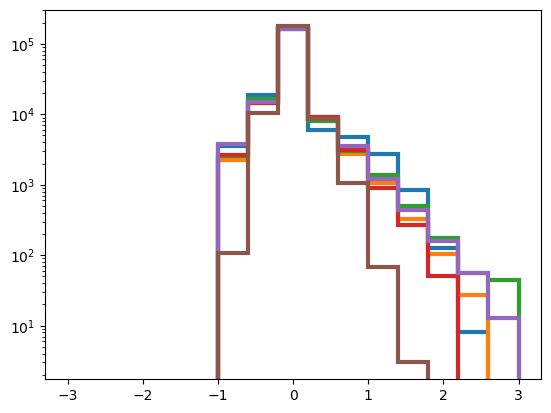

In [112]:
for i in range(len(bins)):
    plt.hist(delta_bins_s[i].ravel(), bins = np.arange(-3.0, 3.1, 0.4), histtype='step', linewidth=3)
plt.yscale('log')
plt.show()

In [113]:
for i in range(len(bins)):
    print(np.nanmean(delta_bins_s[i][mask]))   # should be ~0
    print(np.nanstd(delta_bins_s[i][mask]))    # reasonable scatter

0.016707564246971025
0.5695540975139382
0.0002561644460191719
0.4346059462686341
0.005362509450135574
0.5164547688506184
-0.003674678012861295
0.43323016583404367
-0.0010963987560684795
0.4968525477355339
-0.0008083257555438256
0.26060931872664816


<Figure size 640x480 with 0 Axes>

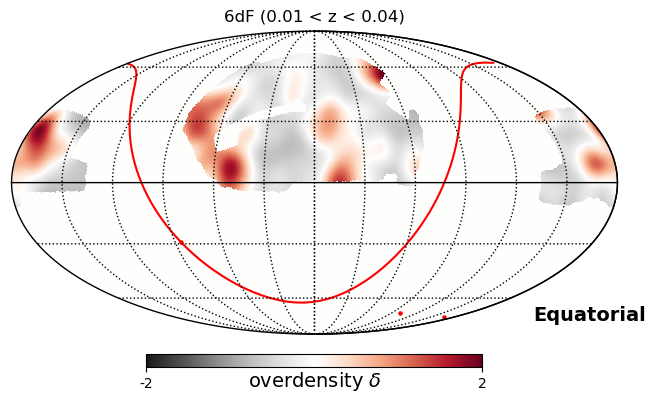

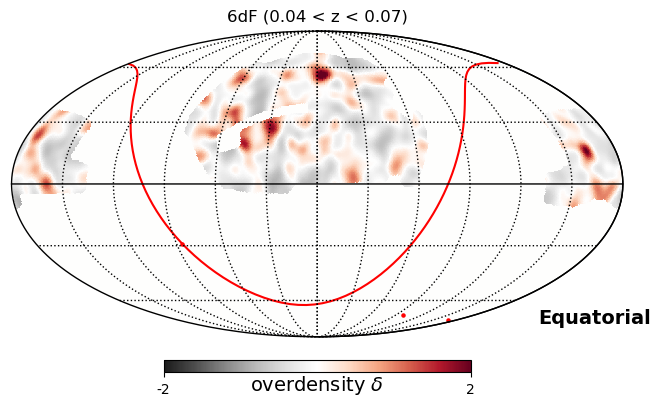

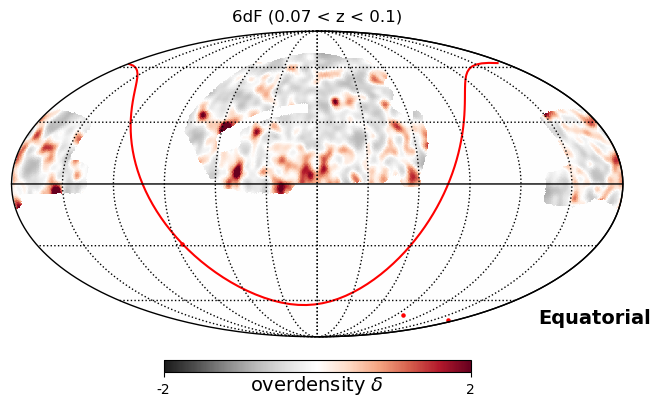

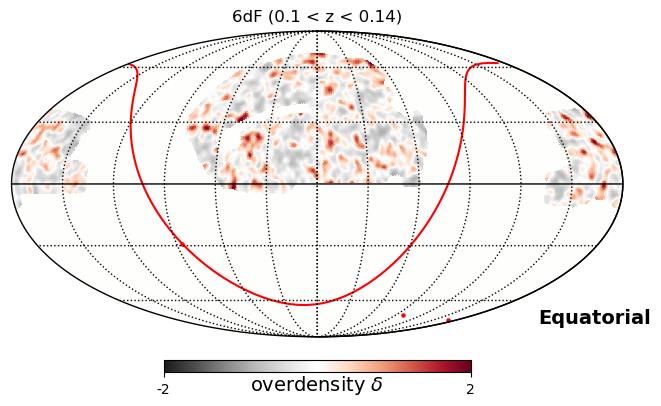

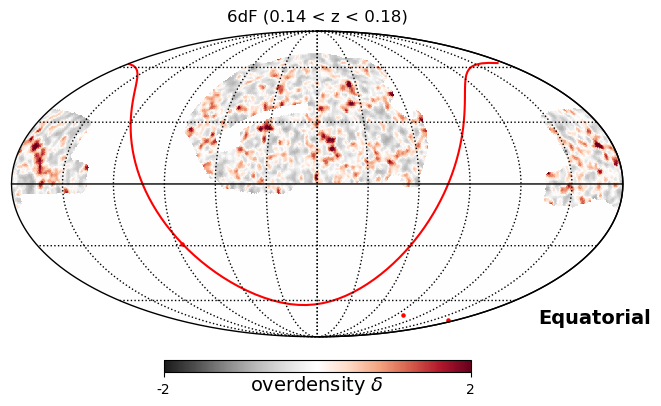

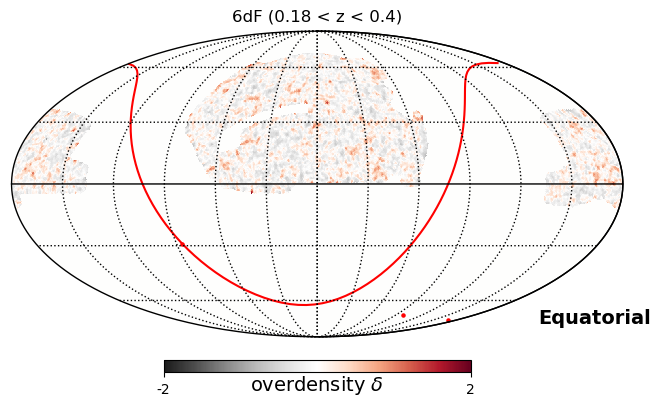

In [114]:
fig = plt.figure(figsize=(7, 4), num=1)

for i in range(len(bins)):
    plt.figure()
    hp.mollview(delta_bins_s[i] * mask, cmap='RdGy_r', min=-2, max=2, rot=(180, 0, 0), coord='C', title=f"6dF ({bins[i][0]} < z < {bins[i][1]})",
                unit=r"overdensity $\delta$", fig=1, xsize=900)
    hp.projscatter(theta_gal, phi_gal, coord=['G', 'C'], marker='o', color='red', s=5)
    hp.projplot(theta_MW, phi_MW, coord='G', color='red')
    hp.graticule()
    plt.show()